# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [1]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=d3a8bced61fc745245053d133ada16f2f4eadf75639d1ebbf232f0994c9edf17
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [2]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


***

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

## <font color=#05C0F3>**Datos de comentarios de peliculas en IMDB**</font>

In [4]:
# datos = pd.read_csv('/content/drive/MyDrive/Ciencia de Datos/7. Modelo Hackathon/datos/IMDB Dataset SPANISH.csv')
url = "https://media.githubusercontent.com/media/JhonatanO24/sentiment-api-equipo39/refs/heads/Data-Science/data_science/datasets/IMDB%20Dataset%20SPANISH.csv"
datos = pd.read_csv(url)

In [5]:
datos = datos[['review_es', 'sentimiento']]

In [6]:
display(datos)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo


***

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [7]:
datos.head(10)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
5,Probablemente mi película favorita de todos lo...,positivo
6,Seguro que me gustaría ver una resurrección de...,positivo
7,"Este espectáculo fue una idea increíble, fresc...",negativo
8,Alentados por los comentarios positivos sobre ...,negativo
9,"Si te gusta la risa original desgarradora, te ...",positivo


In [8]:
datos.tail(10)

,review_es,sentimiento
49990,"Cojo, cojo, cojo !!!Un festival de 90 minutos ...",negativo
49991,"Les Visiteurs, la primera película sobre los v...",negativo
49992,John Garfield interpreta a un marine que está ...,positivo
49993,Robert Colomb tiene dos trabajos a tiempo comp...,negativo
49994,Esta es tu comedia de chatarra típica. Casi no...,negativo
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo
49999,Nadie espera que las películas de Star Trek se...,negativo


In [9]:
datos.sample(10)

,review_es,sentimiento
41756,He visto la matanza de una gran varias veces a...,positivo
1660,Si me pidió que escogiera las mejores película...,positivo
43013,Un gran éxito al lanzarse con audiencias austr...,negativo
40974,Esta puede ser una de las mejores películas qu...,positivo
42530,"Esta película comenzó lentamente, luego ganó i...",positivo
44461,"Muchos de nosotros que estamos dedicados al ""A...",positivo
11928,Hubo un momento en que Joel Schumacher se clas...,negativo
23236,"No hay película con Dennis Hopper, Gary Busey,...",positivo
8844,Tuve grandes expectativas que rodeaban esta pe...,negativo
41917,"Esta película de ""horror"" carece de horror o i...",negativo


### **Verificación de Dimensiones y Tipos**

In [10]:
print(f'Los datos tienen {datos.shape[0]} filas y {datos.shape[1]} columnas.')

Los datos tienen 50000 filas y 2 columnas.


In [11]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_es    50000 non-null  object
 1   sentimiento  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **Eliminando duplicados**

In [12]:
datos.shape

(50000, 2)

In [13]:
datos = datos.drop_duplicates()

In [14]:
datos.shape

(49599, 2)

Se eliminan 401 duplicados

### **Longitud de los textos**

In [15]:
datos.describe()

,review_es,sentimiento
count,49599,49599
unique,49599,2
top,Nadie espera que las películas de Star Trek se...,positivo
freq,1,24886


In [16]:
datos['review_es'].describe()

,review_es
count,49599
unique,49599
top,Nadie espera que las películas de Star Trek se...
freq,1


In [17]:
datos['n_palabras'] = datos['review_es'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
datos['n_palabras']

,n_palabras
0,345
1,161
2,173
3,137
4,237
...,...
49995,170
49996,105
49997,246
49998,232


In [18]:
datos['n_palabras'].describe()

,n_palabras
count,49599.000000
mean,237.436884
std,179.696966
min,6.000000
25%,124.000000
50%,173.000000
75%,293.000000
max,2450.000000


#### Longitud extrema: análisis más profundo de outliers

In [19]:
datos['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,474.0
0.95,623.0
0.99,913.0


In [20]:
pd.set_option('display.max_colwidth', None)

In [21]:
datos.loc[datos['n_palabras'] > 1000, 'review_es'].sample(1)

15159    ***SPOILERS*** ***SPOILERS*** ContinuedFrom here on in the whole movie collapses in on itself First we meet a rogue program with the indication we're gonna get ghosts and vampires and werewolves and the like We get a guy with a retarded accent talking endless garbage, two 'ghosts' that serve no real purpose and have no character what-so-ever and a bunch of henchmen Someone's told me they're vampires (straight out of Blade 2), but they're so undefined I didn't realiseThe funny accented guy with a ridiculous name suffers the same problem as the Oracle, only for far longer and far far worse He has a simple point about cause and effect, makes it, then continues to make it and make it until it becomes convoluted and stupid His final line before walking off is comparable to Storm's "do you know what happens to a toad" line in X-men in levels of utter bland baddness The chocolate cake is such a lazy, pathetic cliche and Monica Bellucci as the wife does nothing other than exactly what we expect the moment we see herAnd then we get another kung fu fight!!! WHY? Neo is, allegedly, The One He can do anything He has the ultimate power and what does he use it for Kung bloody fu all the time And while he can stop 1000 bullets, he still gets cut by a sword and still makes a meal of 5 undecipherable henchmen (vampires?) I wanted to see mind blowing powers I wanted to see him do the wildest, craziest most insane s*** to people because he can do anything I got the same as before without the 'wow'The fabled car chase That can't be bad Well no, it's not It's just not what we've been tyold it was going to be ALL the cool shots from this scene are in the trailer Every one So all possibly Wow has been taken from us so all we now get is a good chase sequence with, guess what, a kung fu fight!!! OK, it's not Neo, but you'd have thought he'd have explained to his closest friends about the reality of the Matrix At least taught them something It's not hard"Hey, Morpheus, don't worry about what happens to you in the matrix It's not real As long as you understand that nothing's real then nothing can really harm you"There you go SimpleOK, so the chase is not bad It's never boring and it doesn't seem like 16 minutes It's just so underwhelming And still, it gets worseThe final climax to the movie is quite probably the worst imaginable They have this whole elaborate plan that involves three crews They then only show it sporadically between Morpheus's over long, super preachy, monologue To make it worse, they never clearly define what this plan that needs 3 teams is You know basically, but you don't know who's doing what, when, so when one crew goes down you just don't care and you don't know how this is going to affect what goes onI'll sum it up though, it happens so Trinity can get back into the Matrix to setup the end That's the only reason it happens Which raises the question, why did they need to send 6 people originally? Trinity gets in in five minutes by herself!Neo's journey to the centre of the Matrix (so to speak) is handled equally lazily Ooohhh!!! He runs into another 100 Agent Smiths!!! Woooooo!!! That must've taken a lot of thought Only now they're in a corridor so the fight has no scale and is over in a moment Man, what a grand finale!!!And then the Architect!!!Remember everything I said was bad about the Oracle and the foreign guy? Add them together and double it, that's how truly appalling the Architect is The only reasonable potential of him is he's about to set up the cliffhanging climaxAnd then he blows it!Let's look at the options he gives Neo Choose one door and all humanity dies (except 27!!!) Choose the other and all humanity dies!!! Considering choice is something this film tries to explore it doesn't really give it's hero one If he had a choice of Save humanity and the missus dies or Save the missus and kill humanity there's the potnetial for inner torment and tension Also, with Trinity being mid fall, the potential of a real 

In [22]:
datos[['review_es', 'n_palabras']].query('n_palabras > 500').sample(10)

review_es  \
36970                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Películas como Chocolat, Beau Travail, y otros han impulsado a la Directora Francesa Claire Denis en el Top Echelon de los cineastas más únicos y logrados de los cineastas y su película de 2004, el intruso (L'intrus) se suma a la profundidad de su portafolio. Un poema cinemático que transmite un estado de ánimo de soledad y pérdida, la película proporciona un vistazo a la psique de un hombre que se está deteriorando física y mentalmente y que viaja a varias partes del mundo que buscan la redención y la paz, pero le resulta difícil conseguir . Basado libremente en la memoria de Jean-Luc Nancy de un trasplante de corazón, el intruso es una película de tal opacidad implacable que incluso después de dos visitas es difícil de describirlo en términos que no sean subjetivos e impresionistas. Ellouis Trebor (Michael Subor) es un hombre En sus setenta, que probablemente muere de afección cardíaca y que, como el profesor en las fresas silvestres de Ingmar Bergman, intenta llegar a un acuerdo con los errores de su vida mientras él tiene tiempo. Está claro que está físicamente escarpado y muy rico, pero parece emocionalmente drenado y la mirada en su rostro es una de resignación tranquila. Aunque solo vemos un episodio de violencia, donde se saca de la cama en medio de la noche para matar a un intruso, hay un siniestro sentido sobre él. Él podría ser un oficial de inteligencia, un agente extranjero o un hombre de éxito. Lo que sea, lo que sea, al parecer, está bajo algún tipo de vigilancia y actúa como un hombre que ha estado involucrado en el deficie penal y ahora ahora es capaz de ver las consecuencias. Los primeros planos faciales en toda la película crean un fuerte sentido de aislamiento. Vive con sus perros en una cabaña en las montañas de Jura cerca de la frontera francesa-suiza y tiene un hijo alejado Sidney (Gregoire Collin) a quien ha descuidado durante mucho tiempo. Sidney vive cerca con su esposa Antoinette (Florence Loireet-Caille) y sus dos hijos. En una escena reveladora, se encuentra con su padre en la calle y le llama un lunático, pero eso no le impide tomar su dinero. Cuando se abre la película, nos encontramos con Antoinette, una guardia fronteriza suiza, que alberga una furgoneta con Un perro entrenado para olfatee un poco de contrabando. Cuando llega a casa, ella es recibida por su marido que le pregunta con la lengua en la mejilla si tiene "cualquier cosa para declarar". Aparte de estos tres individuos, las personas y circunstancias que vemos durante el resto de la película pueden existir solo en la imaginación de Louis. Louis tiene tres mujeres en su vida y nos encontramos con ellos todos en la primera media hora de la película: un farmacéutico (Bambou) que prepara su medicamento, un vecino (Béatrice Dalle) que es criador de perros que se niega a cuidar a sus perros cuando él va lejos, en un viaje, diciéndole que son tan locos como lo es, y un joven distribuidor de órganos ruso (Katia Golubeva), quien le dice que quiere un "corazón de hombre joven". Sin embargo, ella lo acelere a lo largo de la película, pero al parecer, es solo en su mente. En la última sección de la película, Luis viaja a Corea del Sur en busca de un trasplante de corazón y a Tahití para entregar un regalo a un hijo diferente, uno de quien no ha visto durante muchos años o tal vez nunca ha visto. Su trasplante de corazón, sin embargo, parece ser una met

In [23]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [24]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,24886
negativo,24713


In [25]:
datos['sentimiento'].value_counts(normalize=True)

,proportion
sentimiento,
positivo,0.501744
negativo,0.498256


In [26]:
datos.sample(10)

,review_es,sentimiento,n_palabras
49837,Qué horrible película.Esta película fue tan fu...,negativo,107
29745,"¡Como un fanático de los zombies, realmente am...",positivo,112
49828,"""El odio de un minuto"" es posiblemente una de ...",positivo,285
30162,Al seguir a la estrella de Dylan Moran del enc...,negativo,388
48674,"Realmente, realmente, quería ver esta película...",negativo,381
19349,La sensación de esta película fue increíble.El...,positivo,155
5053,No debe confundirse con el thriller sobrenatur...,negativo,316
17768,Después de una historia de triángulo de amor e...,positivo,385
33302,"Como varios carteles han ""insinuado"", esta es ...",negativo,157
25540,El beguiled es una de esas películas bajo vist...,positivo,661


### **Graficos**

In [27]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [28]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [29]:
color_primario = "#05C0F3"
color_secundario = "#F90499"

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

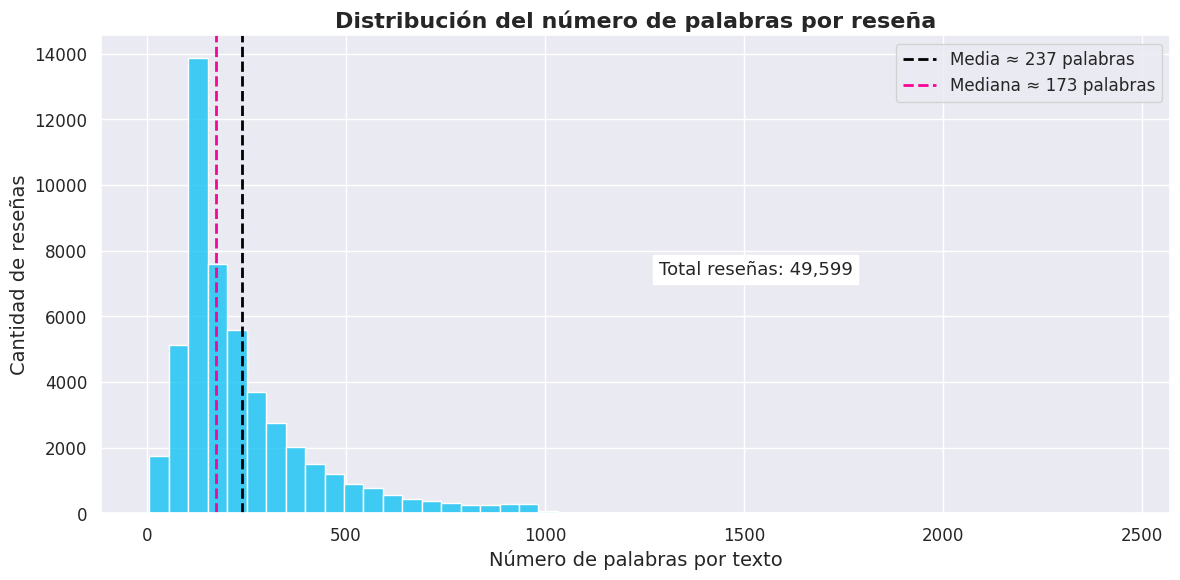

In [30]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      datos['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(datos):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

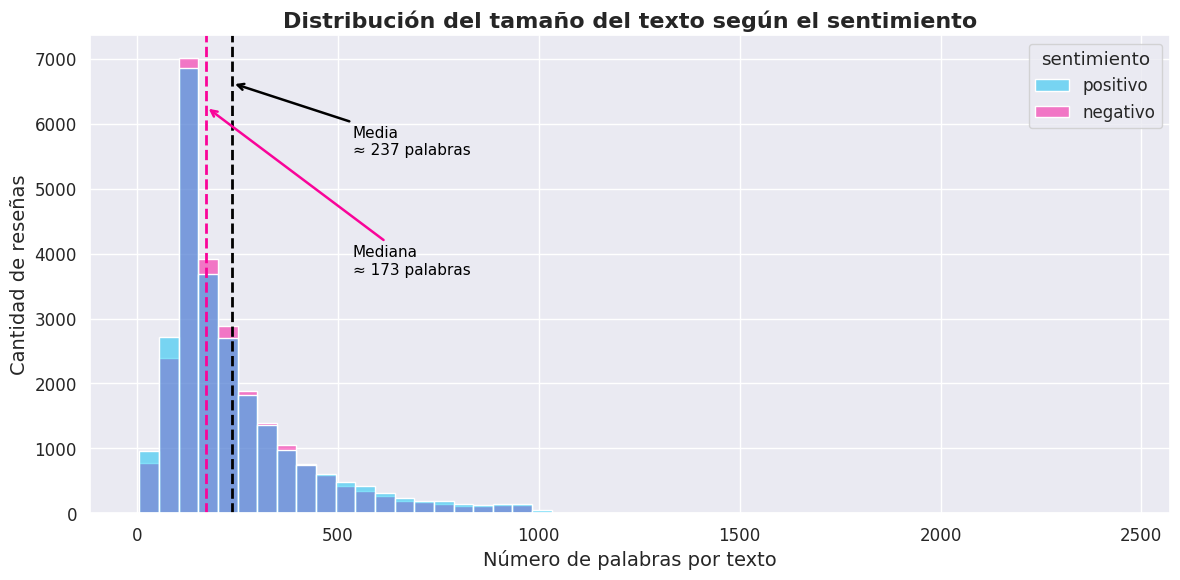

In [31]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = datos,
      x = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario],
      bins=50
  )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  ax.axvline(
      mediana,
      color = color_secundario,
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = color_secundario,
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

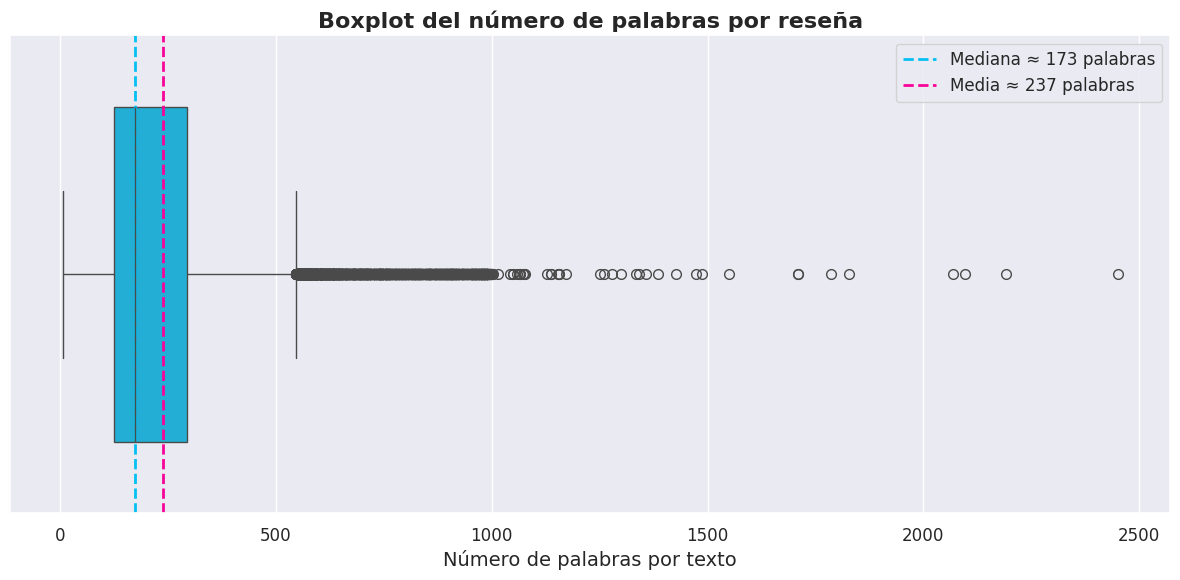

In [32]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = datos['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = datos['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

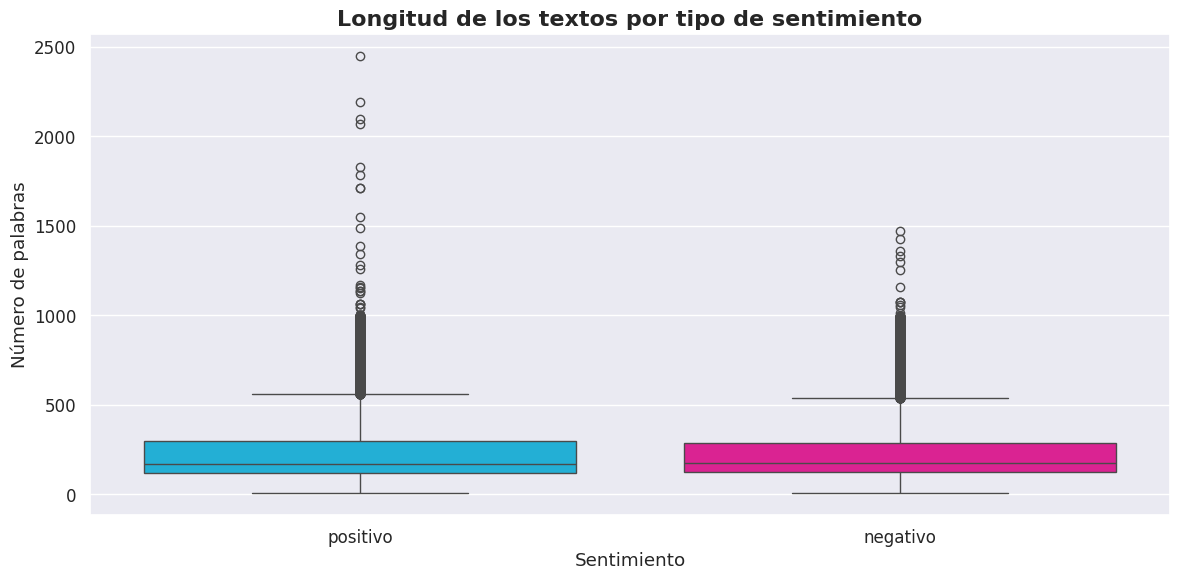

In [33]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = datos,
      x='sentimiento',
      y = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

* El conjunto de datos presenta algunos registros duplicados pero pocos comparados a la cantidad de datos, lo que indica una buena calidad inicial, además de que con la limpieza se eliminan para evitar sesgos por repetición de observaciones durante el entrenamiento del modelo.

* Las columnas cuentan con tipos de datos adecuados para el análisis, permitiendo trabajar correctamente con texto y variables categóricas.

#### **Conclusiones sobre la longitud de los textos**

- La longitud de las reseñas presenta alta variabilidad, con una media aproximada de 237 palabras y valores extremos que alcanzan más de 2400 palabras.

- La diferencia entre media y mediana indica una distribución sesgada a la derecha, confirmada por la presencia de múltiples outliers visibles en el boxplot.

- La mayoría de los textos se concentra en rangos bajos y medios de longitud, mientras que un pequeño porcentaje de reseñas muy extensas genera una cola larga en la distribución.

#### **Conclusiones sobre el idioma de los datos**

- Se detectó la presencia de reseñas en más de un idioma (español e inglés) dentro de la columna utilizada para el entrenamiento.

- Esto introduce un posible ruido lingüístico, ya que TF-IDF tratará palabras de ambos idiomas como parte del mismo vocabulario.

#### **Conclusión general del EDA**

El análisis exploratorio confirma que el conjunto de datos es apto para entrenar un modelo de análisis de sentimiento, cumpliendo con los requisitos del MVP propuesto.

Si bien existen desafíos como la alta variabilidad en la longitud de los textos y la presencia de múltiples idiomas, estos no impiden la construcción de un modelo inicial basado en TF-IDF y regresión logística.

El EDA permite identificar claramente oportunidades de mejora que pueden abordarse en iteraciones futuras, alineándose con el enfoque incremental esperado.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [34]:
datos.isnull().sum()

,0
review_es,0
sentimiento,0
n_palabras,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [35]:
def detectar_idioma(texto):
    try:
        return detect(texto) #Se usa la biblioteca langdetect
    except:
        return "desconocido"

In [36]:
datos.shape

(49599, 3)

In [37]:
#Columna con el idioma de la reseña (El procesamiento tardará)
datos['idioma_detectado'] = datos['review_es'].apply(detectar_idioma)

In [38]:
datos_limpios = datos[datos['idioma_detectado'] == 'es'].copy() #Solo guarda los datos en español

In [39]:
filas_originales = len(datos)
filas_limpias = len(datos_limpios)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 1815 filas que no estaban en español


In [40]:
datos = datos_limpios

In [41]:
datos.shape

(47784, 4)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [42]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23935
negativo,23849


In [43]:
print("\nEstadísticas de longitud antes del balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23935.0  230.686693  166.550784  10.0  122.0  170.0  290.0  955.0


#### Eliminar las reseñas más grandes (partes del sesgo) para mantener el equilibrio en el número de reseñas de ambos sentimientos

In [44]:
datos_pos = datos[datos['sentimiento'] == 'positivo'].copy()
datos_neg = datos[datos['sentimiento'] == 'negativo'].copy()

In [45]:
diferencia = len(datos_pos) - len(datos_neg)
print(f"Hay {diferencia} reseñas positivas extras")

Hay 86 reseñas positivas extras


In [46]:
datos_pos_balanceado = datos_pos.sort_values(by='n_palabras', ascending=False).iloc[diferencia:]
len(datos_pos_balanceado)

23849

In [47]:
datos_equilibrados = pd.concat([datos_pos_balanceado, datos_neg])

In [48]:
datos = shuffle(datos_equilibrados, random_state=42).reset_index(drop=True)

In [49]:
datos['sentimiento'].value_counts()

,count
sentimiento,
negativo,23849
positivo,23849


In [50]:
print("\nEstadísticas de longitud tras el balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud tras el balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23849.0  228.243406  161.791663  10.0  121.0  169.0  289.0  883.0


#### Estandarización a minúsculas

In [51]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es
...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es


In [52]:
datos['review_es_limpio'] = datos['review_es'].str.lower()

In [53]:
datos['review_es_limpio']

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,"¿nunca debo ir a este hospital [o hospicio, si..."
2,"alan rudolph es un director tan así, sin ese t..."
3,alquilé esto pensando que sería bastante bueno...
4,"la serie azul planet es, sin lugar a dudas, un..."
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...
47695,"oh hombre, ¿esta película alguna vez muerde!si..."
47696,"sin duda, una de las grandes obras maestras de..."


#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [54]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)

In [55]:
display(datos['review_es_limpio'])

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguo...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

#### Eliminar espacios múltiples

In [56]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [57]:
display(datos['review_es_limpio'])

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguos ...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [58]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado,review_es_limpio
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es,me derrota absolutamente por qué godard se tom...
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es,nunca debo ir a este hospital o hospicio si qu...
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es,alan rudolph es un director tan así sin ese to...
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es,alquilé esto pensando que sería bastante bueno...
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es,la serie azul planet es sin lugar a dudas uno ...
...,...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es,minutos de esto es cruel y amo a los antiguos ...
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es,oh hombre esta película alguna vez muerdesi al...
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es,sin duda una de las grandes obras maestras de ...


### **Definición de variables de entrada (X) y salida (y)**

In [59]:
X = datos['review_es_limpio']

In [60]:
display(X)

,review_es_limpio
0,me derrota absolutamente por qué godard se tom...
1,nunca debo ir a este hospital o hospicio si qu...
2,alan rudolph es un director tan así sin ese to...
3,alquilé esto pensando que sería bastante bueno...
4,la serie azul planet es sin lugar a dudas uno ...
...,...
47693,crecí en la ciudad de nueva york y todas las t...
47694,minutos de esto es cruel y amo a los antiguos ...
47695,oh hombre esta película alguna vez muerdesi al...
47696,sin duda una de las grandes obras maestras de ...


In [61]:
y = datos['sentimiento'].map({
    'negativo': 0,
    'positivo': 1
})

In [62]:
display(y)

,sentimiento
0,0
1,1
2,0
3,0
4,1
...,...
47693,1
47694,0
47695,0
47696,1


### **División de datos en conjuntos de entrenamiento y prueba**

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [64]:
stopwords_es = stopwords.words('spanish')

In [65]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_es,
    ngram_range = (1, 2),
    max_features = 5000,
    min_df = 5,
    max_df = 0.9
)

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [66]:
X_train_tfidf  = vectorizador.fit_transform(X_train)

In [67]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2525164 stored elements and shape (33388, 5000)>

### **Transformación del conjunto de prueba**

In [68]:
X_test_tfidf = vectorizador.transform(X_test)

In [69]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1079896 stored elements and shape (14310, 5000)>

#### Dimension

In [70]:
X_train_tfidf.shape

(33388, 5000)

In [71]:
X_test_tfidf.shape

(14310, 5000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [72]:
modelo = LogisticRegression(random_state=42)

#### Entrenamiento del modelo

In [73]:
modelo.fit(X_train_tfidf, y_train, )

LogisticRegression(random_state=42)

#### Predicciones

In [74]:
y_pred = modelo.predict(X_test_tfidf)

In [75]:
y_proba = modelo.predict_proba(X_test_tfidf) # Obtiene las probabilidades, esencial para el contrato de la API

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [76]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['negativo', 'positivo']))


Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.88      0.86      0.87      7170
    positivo       0.86      0.88      0.87      7140

    accuracy                           0.87     14310
   macro avg       0.87      0.87      0.87     14310
weighted avg       0.87      0.87      0.87     14310



#### Obtener palabras más significativas para cada sentimiento

In [77]:
palabras = vectorizador.get_feature_names_out()
coefs = modelo.coef_.flatten()
datos_palabras = pd.DataFrame({'palabra': palabras, 'coeficiente': coefs})

In [78]:
top_pos = datos_palabras.nlargest(10, 'coeficiente')
top_neg = datos_palabras.nsmallest(10, 'coeficiente')
top_palabras = pd.concat([top_pos, top_neg])

/tmp/ipython-input-3743336128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')


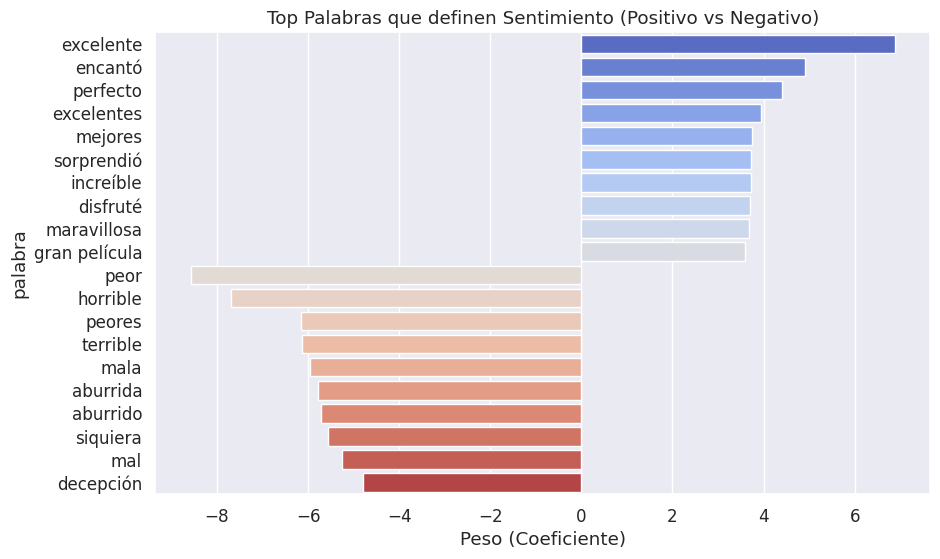

In [79]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')
plt.title('Top Palabras que definen Sentimiento (Positivo vs Negativo)')
plt.xlabel('Peso (Coeficiente)')
plt.show()

#### Análisis de Errores


In [80]:
datos_test = X_test.to_frame(name='review').copy()
datos_test['real'] = y_test
datos_test['prediccion'] = y_pred

In [81]:
errores = datos_test[datos_test['real'] != datos_test['prediccion']]
print(f"Total de errores: {len(errores)} de {len(datos_test)}")

Total de errores: 1890 de 14310


In [82]:
errores.sample(10)

,review,real,prediccion
1912,la leyenda de dragoon es uno de esos juegos po...,1,0
41767,vi el messiah hace unos meses y no pudimos ver...,1,0
11852,fue genial ver algunas de mis estrellas favori...,0,1
4047,el problema con otros actores fundidos en el r...,1,0
24654,la película la puerta del cielo fue una buena ...,0,1
25296,en las montañas de japón el joven artista de s...,0,1
15999,el agua muestra la difícil situación de las vi...,0,1
41138,no voy a decir la historia de la película como...,0,1
14971,entonces qué constituye una verdadera película...,1,0
4108,como parte de la celebración del lanzamiento d...,1,0


##### Falsos Positivos (Eran negativos y se clasificaron como positivos)

Son los errores más importantes y que se tienen que destacar, dado que en los requisitos (y en general para cualquier modelo de atención al cliente) es peor ignorar los comentarios negativos y no darles atención (falsos positivos)

In [83]:
for i, row in errores[errores['prediccion'] == 1].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: todavía tengo que leer una revisión profesional negativa de esta películasupongo que debo haber perdido algoel comienzo es intrigante los tres personajes principales se reúnen a altas horas de la noche en una barra de otro modo vacía y entre sí con historias inventadasesa es la mejor partedespués de...
Real: 0 | Pred: 1

Review: otra película que hace peor la historia de los chicos de la playa de lo que esrecuerdo especialmente la escena cuando brian dice que es para dejar de fumar y los otros niños lo llaman traidorno sucedí así y al igual que la película indica al principio es que algunas escenas se requieren sobrepasadas...
Real: 0 | Pred: 1

Review: esta película es sobre una brecha que existe entre el mundo real y el mundo de los muertos hay un montón de mumbojumbo sobre internet es decir si instala un programa en la computadora se ve a la gente muerta al igual que si juega una cinta de video morirá en ringu francamente la mayoría de esto pare...
Real: 0 | Pred: 1



##### Falsos Negativos (Eran positivos y se clasificaron como negativos)

In [84]:
for i, row in errores[errores['prediccion'] == 0].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: esto no es una película seria y no pretende ser pero no es tan malo como algunas de sus críticas su título y los primeros diez minutos le llevan a esperar la parcela es muy tonta pero esto se suma a ladiversión y entusiasmo alegre que corre por la películalos personajes se desempeñan con simpatía y ...
Real: 1 | Pred: 0

Review: oceans if you robes cincuenta millones de dólares te encontrarán alan rickman como hans gruber muere duro este adagio ciertamente suena verdadero en esta secuela terry benedicto ha sido informado de que danny ocean y sus compadres fueron los que lo derribaron y ahora lo quiere de nuevo la pandilla d...
Real: 1 | Pred: 0

Review: por alguna razón siempre disfruto de las películas que las personas odian cuando realmente no creo que sean tan malas y esta es una de esas películas en el caso de esta película creo que es demasiado criticado demasiado realmente no es tan malo de una película en absoluto de hecho creo que esta es u...
Real: 1 | Pred: 0



#### Matriz de confusión


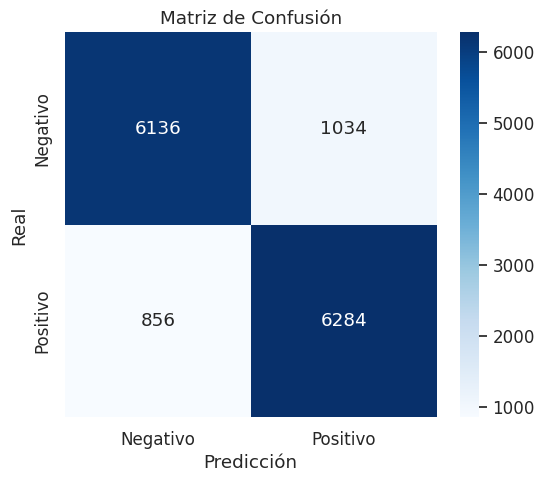

In [85]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

La matriz de confusión muestra como hay un poco más de falsos positivos que de falsos negativos, para este ejemplo, nos importa mucho más las reseñas negativas para poder atender el disgusto de los clientes. Por lo tanto, es preferible tener menos falsos positivos (reseñas negativas tomadas como positivas) aunque eso conlleve a tener un poco más de falsos negativos.

#### Obtener el mejor umbral para reducir falsos positivos

In [93]:
pipeline_test = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

pipeline_test.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...])),
                ('clf', LogisticRegression(random_state=42))])

In [94]:
probs = pipeline_test.predict_proba(X_test)[:, 1]

In [103]:
def probar_umbral(umbral):
    # Si la probabilidad es mayor al umbral, es 'positivo', si no 'negativo'
    preds_ajustadas = np.where(probs > umbral, 1, 0)

    # Generar matriz de confusión con el nuevo umbral
    cm = confusion_matrix(y_test, preds_ajustadas, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return fp, fn, cm

In [108]:
umbrales = [0.5, 0.6, 0.63, 0.64, 0.645, 0.65, 0.655, 0.66, 0.67, 0.7, 0.8]

In [109]:
print(f"{'Umbral':<10} {'Falsos Positivos (Riesgo)':<25} {'Falsos Negativos (Revisión extra)'}")
print("-" * 70)
for u in umbrales:
    fp, fn, _ = probar_umbral(u)
    print(f"{u:<10} {fp:<25} {fn}")

Umbral     Falsos Positivos (Riesgo) Falsos Negativos (Revisión extra)
----------------------------------------------------------------------
0.5        843                       675
0.6        527                       1080
0.63       451                       1251
0.64       415                       1300
0.645      399                       1331
0.65       381                       1358
0.655      372                       1387
0.66       360                       1414
0.67       336                       1489
0.7        273                       1695
0.8        127                       2629


#### Usando el mejor umbral

Al tener un umbral más alto, es más estricto para que el modelo clasifique una reseña como positiva, lo que reduce significativamente la probabilidad de no atender una reseña negativa.

El mejor umbral fue de ***0.65***, con lo que se reducen la cantidad de falsos positivos, pero sin llevar a una enorme cantidad de falsos negativos.
Considerando los requisitos del proyecto, es priorizable detectar correctamente las reseñas negativas que las positivas.

In [113]:
mejor_umbral = 0.65
y_pred_final = np.where(probs > mejor_umbral, 1, 0)


--- Matriz de Confusión con Umbral 0.65 ---


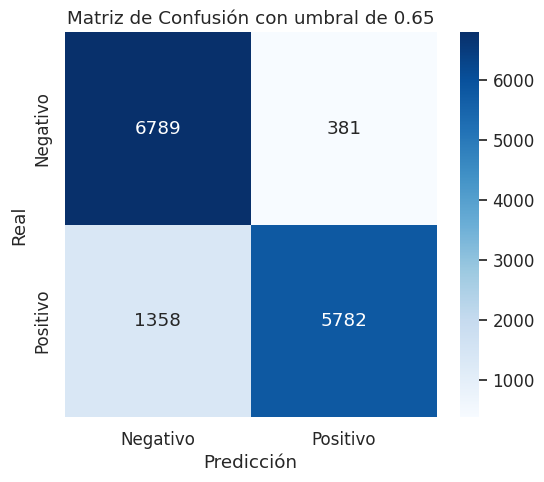

In [116]:
print(f"\n--- Matriz de Confusión con Umbral {mejor_umbral} ---")
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión con umbral de 0.65')
plt.show()

## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el Back-End pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [117]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

### **Reentrenar el pipeline con X y Y**

In [118]:
pipeline_final.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...])),
                ('clf', LogisticRegression(random_state=42))])

### **Serialización**

In [119]:
joblib.dump(pipeline_final, 'sentiment_model_1.2.joblib')

['sentiment_model_1.2.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [120]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [121]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [122]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [123]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [124]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [0], Probabilidad: 0.63


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

~~~
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}

~~~

**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

### Archivo requirements.txt
### Dentro del archivo .txt el siguiente texto:

- fastapi
- uvicorn
- joblib
- scikit-learn
- nltk
- numpy

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 2. Encender el servidor: uvicorn app:app --reload

### Arhivo ipynb, Modelo_hackathon.ipynb
El archivo .ipynb crea el archivo (sentiment_model.joblib)
Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): `pip install -r requirements.txt`
- 2. Encender el servidor: `uvicorn app:app --reload`